# CPSC 480 – Project #1: Predicting Abalone Age with Regression

**Dataset:** Abalone, UCI Machine Learning Repository — https://archive.ics.uci.edu/dataset/1/abalone

# Description


Using a dataset provided by UC Irvine, we design a model to estimate the age of an abalone snail using easy to obtain measurments. Instead the model will use the total, shucked, and viscera weight; sex, outside dimensions, and visible rings of the snail shell. Using various model designs, we will compare the success of each to find consistency and accuracy. First the dataset will be split into training and test sets, as well as implementing feature names for the columns as the dataset has no labels. Then using regression, random forest, descision tree, and SVR to compare thier accuracies on the same training and test sets. All steps of data insight and model training will be visualized using various graphs and plots.

# Setup

In [1]:
# ---- Environment checks ----
# Python >= 3.5 is required
import sys
assert sys.version_info >= (3, 5)
%pip install scikit-learn pandas matplotlib scipy
%pip install --upgrade numpy scipy scikit-learn

# Scikit-Learn >= 0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"


# ---- Common imports ----
import numpy as np    # numerical arrays
import pandas as pd   # dataframes
import os             # file paths and folders

# ---- Plot settings ----
# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)    # axis label font size
mpl.rc('xtick', labelsize=12)   # x tick label font size
mpl.rc('ytick', labelsize=12)   # y tick label font size

# ---- Folder for saved figures ----
# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "abalone_regression"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)   # create the folder if it doesn't exist yet

# Helper that saves the current matplotlib figure to IMAGES_PATH
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()   # trim extra whitespace so labels aren't cut off
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Make this notebook's output stable across runs
np.random.seed(42)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# 2. Get the Data

## Download the Data
The raw file `abalone.data` is a CSV **without a header row**, so we supply the column names from the dataset documentation. Lengths are in mm and weights in grams (both scaled down by 200 in the original data).

In [2]:
import os
import urllib.request         # package to import dataset
import pandas as pd           # utilize pandas to read csv file

DOWNLOAD_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"        # variable holding dataset URL
ABALONE_PATH = os.path.join("datasets", "abalone")   # local folder where the data is stored

# function to request dataset and make a local file
def fetch_abalone_data(abalone_url=DOWNLOAD_URL, abalone_path=ABALONE_PATH):
    os.makedirs(abalone_path, exist_ok=True)   # create the local folder if needed
    data_path = os.path.join(abalone_path, "abalone.data")
    # only download if we don't already have a local copy
    if not os.path.isfile(data_path):
        urllib.request.urlretrieve(abalone_url, data_path)

# define dataset columns to include as header row (dataset features)
# (the raw file has no header, so names come from the UCI documentation; "Rings" is the target)
COLUMNS = ["Sex", "Length", "Diameter", "Height", "Whole_weight",
           "Shucked_weight", "Viscera_weight", "Shell_weight", "Rings"]

# function to read to requested dataset file with the new column headers
def load_abalone_data(abalone_path=ABALONE_PATH):
    data_path = os.path.join(abalone_path, "abalone.data")
    # header=None: file has no header row; names=COLUMNS: supply our own
    return pd.read_csv(data_path, header=None, names=COLUMNS)

In [3]:
# Download the data (if needed) and load it into a DataFrame
fetch_abalone_data()
abalone = load_abalone_data()

## Take a Quick Look at the Data Structure

In [4]:
abalone.head() # first five individuals with column header

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [5]:
abalone.info() # dataset features and datatypes (also shows non-null counts)

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 293.8 KB


4,177 instances, 9 columns, no null values reported. `Sex` is the only non-numeric attribute (M = male, F = female, I = infant). Everything else is a float except the target `Rings`, which is an integer.

In [6]:
abalone["Sex"].value_counts()   # how many male (M), female (F), and infant (I) abalone

Sex
M    1528
I    1342
F    1307
Name: count, dtype: int64

In [7]:
abalone.describe()   # summary stats (count, mean, std, min, quartiles, max) for numeric columns

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


Things that stand out in `describe()`:
- **`Height` has a minimum of 0.** An abalone cannot have zero height, so these are recording errors even though `info()` showed no missing values.
- **`Height` has a maximum of 1.13**, far above its 75th percentile (0.165). That is almost certainly a typo.
- `Rings` ranges from 1 to 29 with a mean near 10: most abalone are young, and a few are very old.

Saving figure attribute_histogram_plots


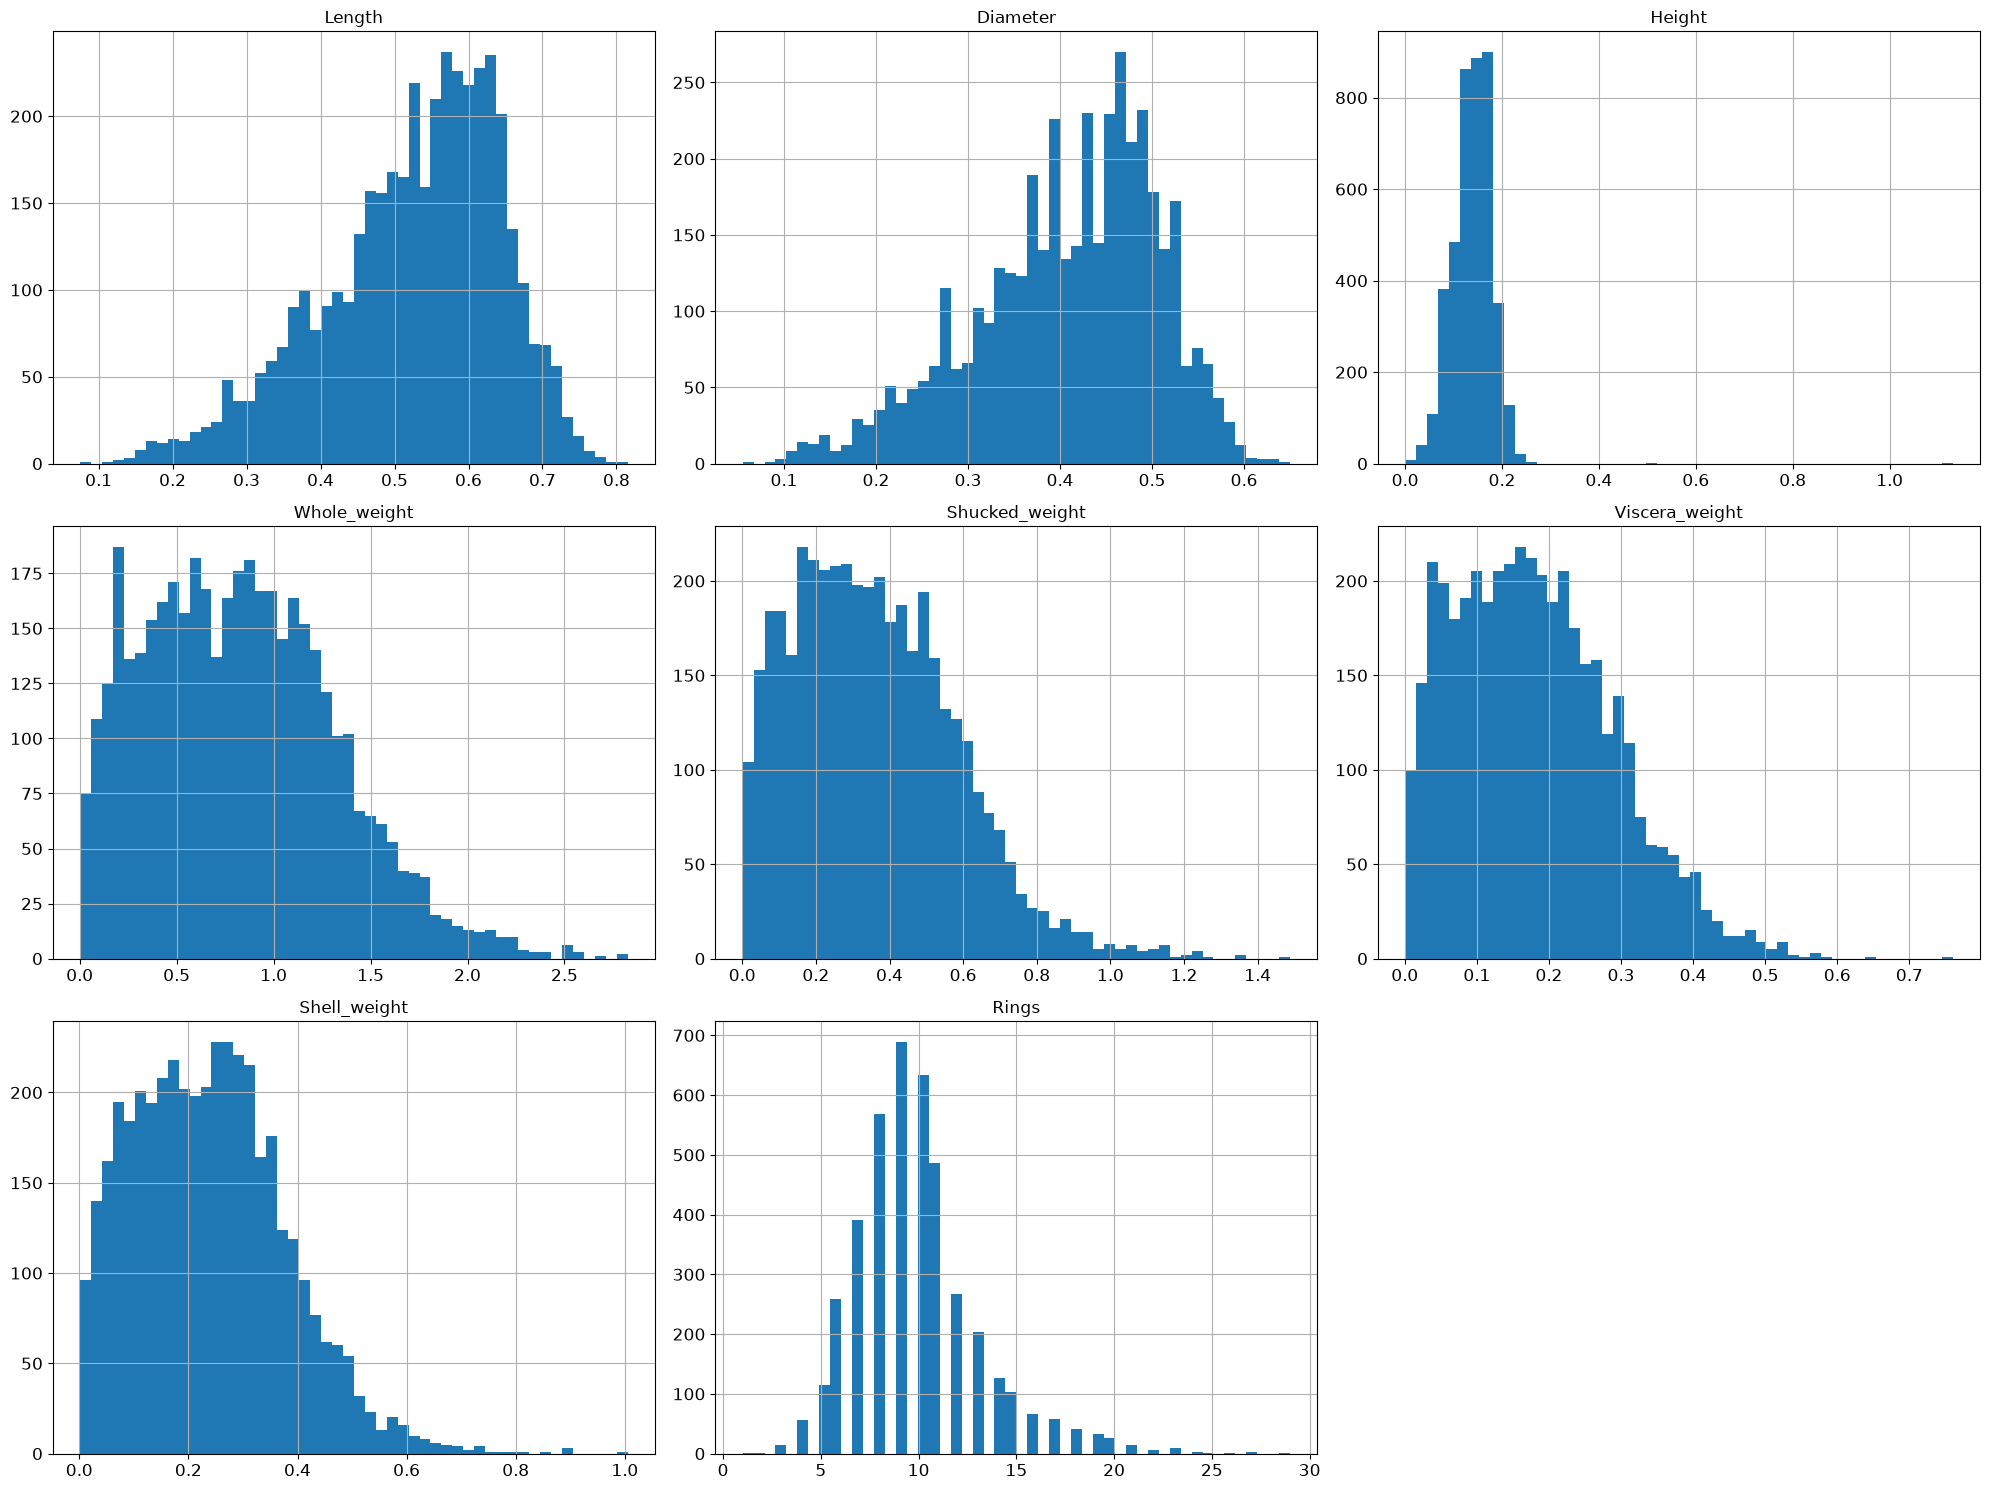

In [8]:
abalone.hist(bins=50, figsize=(20,15))     # render dataset features as histograms
save_fig("attribute_histogram_plots")      # save the figure to the images folder
plt.show()

Most attributes are smoothly distributed. The weight attributes are right-skewed, and `Rings` has a long right tail — old abalone are rare, so the model will have little data to learn from for them.

In [9]:

# Sanity checks for physically impossible values
print("Rows with Height == 0:", (abalone["Height"] == 0).sum())      # an abalone can't have zero height
print("Rows with Height > 0.4:", (abalone["Height"] > 0.4).sum())    # extreme outliers, likely typos
print("Rows where shucked (meat) weight > whole weight:",           # meat can't outweigh the whole animal
      (abalone["Shucked_weight"] > abalone["Whole_weight"]).sum())

Rows with Height == 0: 2
Rows with Height > 0.4: 2
Rows where shucked (meat) weight > whole weight: 4


A few rows are physically impossible: zero height, extreme height, or meat weighing more than the whole animal. We will treat those values as missing and impute them in the preprocessing pipeline.

## Create a Test Set

Shell weight is the attribute most correlated with ring count (checked below), so — as the textbook did with median income — we use **stratified sampling** on binned shell weight. This makes sure the test set represents small, medium, and large abalone in the same proportions as the full dataset. We set the test set aside now, *before* exploring further, to avoid data-snooping bias.

In [10]:
# Bin shell weight into 5 equal-sized groups (quintiles) to use for stratified sampling
abalone["shell_cat"] = pd.qcut(abalone["Shell_weight"], q=5, labels=[1, 2, 3, 4, 5])
abalone["shell_cat"].value_counts().sort_index()   # check each bin has about the same number of rows

shell_cat
1    836
2    836
3    856
4    813
5    836
Name: count, dtype: int64

In [11]:
from sklearn.model_selection import StratifiedShuffleSplit

# One 80/20 train/test split that keeps the shell-weight bin proportions the same in both sets
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(abalone, abalone["shell_cat"]):
    strat_train_set = abalone.loc[train_index]
    strat_test_set = abalone.loc[test_index]

In [12]:
from sklearn.model_selection import train_test_split

# Share of rows in each shell-weight bin
def shell_cat_proportions(data):
    return data["shell_cat"].value_counts() / len(data)

# Plain random split, used only for comparison against the stratified split
train_set, test_set = train_test_split(abalone, test_size=0.2, random_state=42)

# Compare bin proportions: full dataset vs. stratified test set vs. random test set
compare_props = pd.DataFrame({
    "Overall": shell_cat_proportions(abalone),
    "Stratified": shell_cat_proportions(strat_test_set),
    "Random": shell_cat_proportions(test_set),
}).sort_index()
# Percent error relative to the full dataset (smaller = more representative)
compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100
compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
shell_cat,,,,,
1,0.200144,0.199761,0.212919,6.382924,-0.191302
2,0.200144,0.199761,0.180622,-9.753812,-0.191302
3,0.204932,0.205742,0.222488,8.566885,0.395184
4,0.194637,0.194976,0.194976,0.174056,0.174056
5,0.200144,0.199761,0.188995,-5.570214,-0.191302


In [13]:
# Remove the helper column now that the split is done
for set_ in (strat_train_set, strat_test_set):
    set_.drop("shell_cat", axis=1, inplace=True)
abalone = abalone.drop("shell_cat", axis=1)

print(len(strat_train_set), "train +", len(strat_test_set), "test")

3341 train + 836 test


# 3. Discover and Visualize the Data to Gain Insights
We explore a copy of the **training set only**.

In [14]:
# Explore a copy of the training set only, so the test set stays untouched
abalone = strat_train_set.copy()

## Looking for Correlations

In [15]:
# Correlation of every numeric feature with the target (Rings); Sex is excluded because it's text
corr_matrix = abalone.drop("Sex", axis=1).corr()
corr_matrix["Rings"].sort_values(ascending=False)

Rings             1.000000
Shell_weight      0.629898
Diameter          0.575161
Length            0.556772
Height            0.546820
Whole_weight      0.541420
Viscera_weight    0.503506
Shucked_weight    0.420882
Name: Rings, dtype: float64

Every measurement is positively correlated with age (bigger abalone tend to be older), but none above ~0.63. Shell weight is the strongest single predictor. Correlations of 0.4–0.6 suggest a model will help but will not be extremely precise: abalone of the same size can differ in age by several years.

Saving figure scatter_matrix_plot


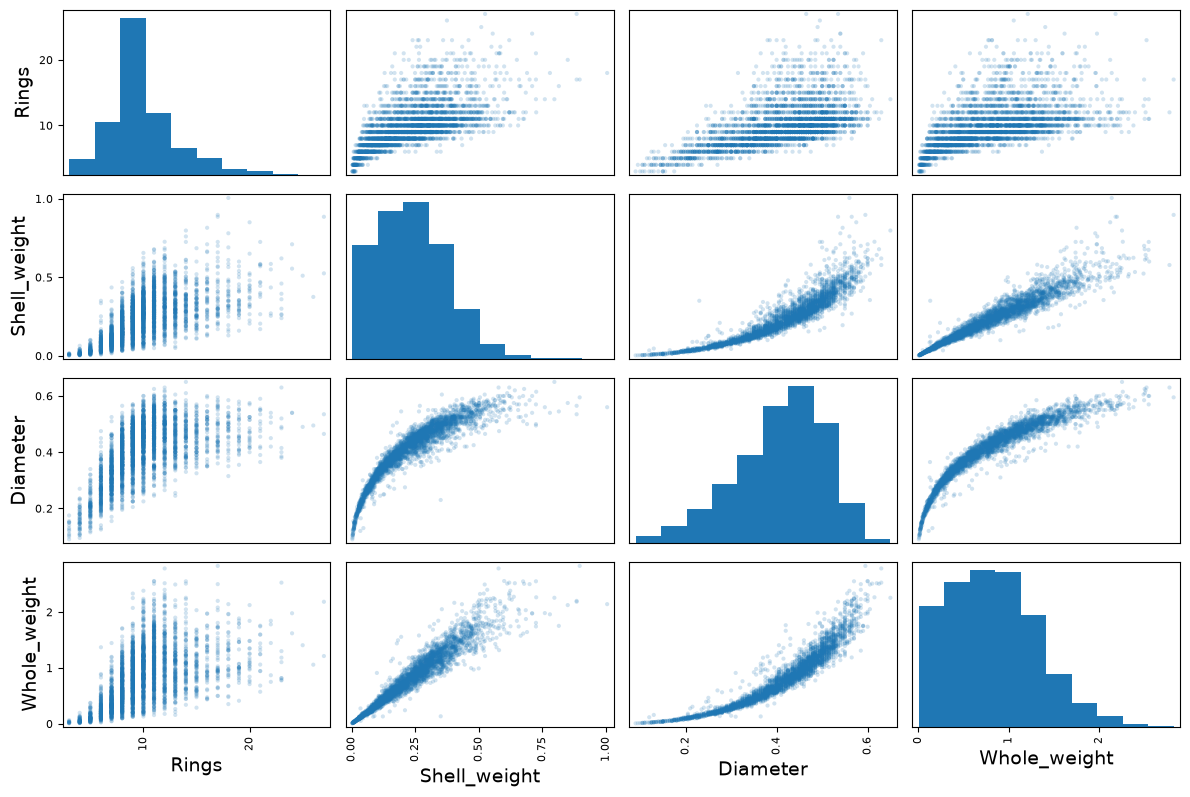

In [16]:
from pandas.plotting import scatter_matrix

# Pairwise scatter plots for the target and a few of the most informative features
attributes = ["Rings", "Shell_weight", "Diameter", "Whole_weight"]
scatter_matrix(abalone[attributes], figsize=(12, 8), alpha=0.2)   # alpha < 1 makes dense areas visible
save_fig("scatter_matrix_plot")
plt.show()

Saving figure shell_weight_vs_rings_scatterplot


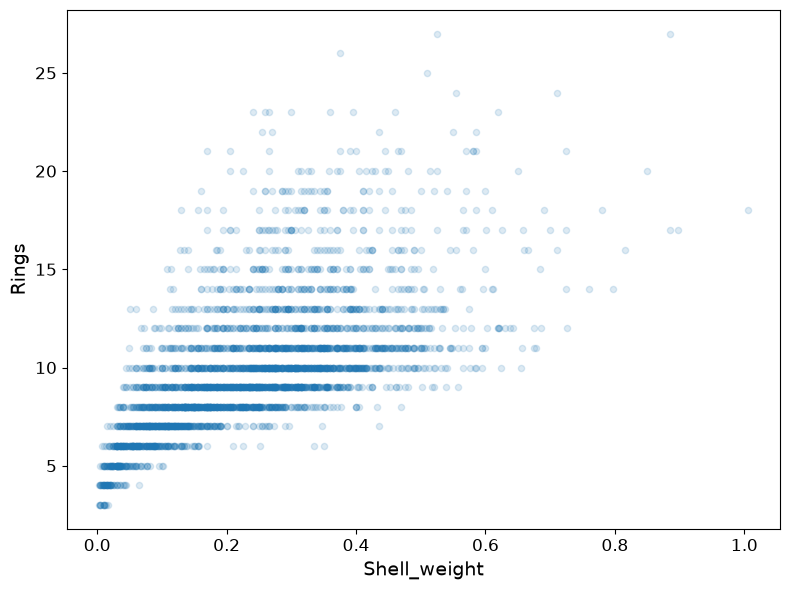

In [17]:
# Zoom in on the strongest predictor: shell weight vs. ring count
abalone.plot(kind="scatter", x="Shell_weight", y="Rings", alpha=0.15, figsize=(8,6))
save_fig("shell_weight_vs_rings_scatterplot")
plt.show()

The relationship between shell weight and rings is clearly **non-linear**: rings rise quickly for light shells, then the cloud fans out. Large abalone vary widely in age — growth slows once an abalone matures, so size stops being a good clock. This suggests non-linear models (trees, forests) may beat linear regression.

Saving figure rings_by_sex_boxplot


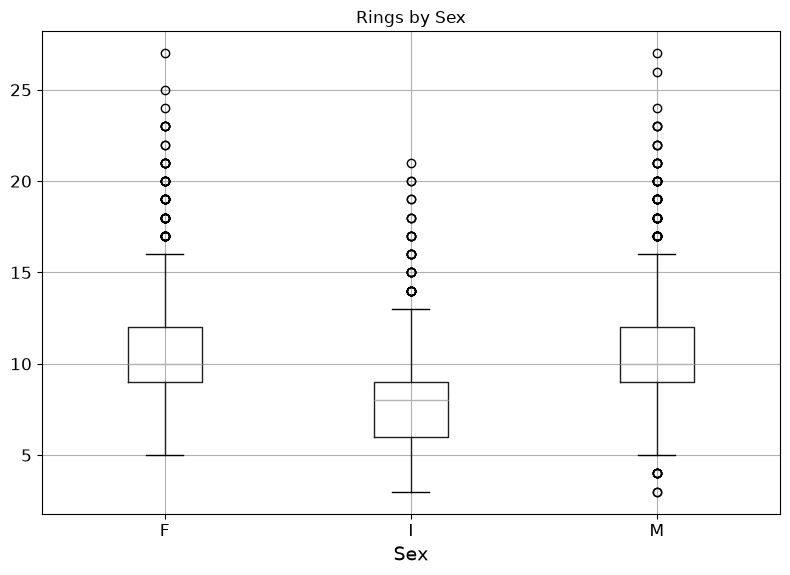

In [18]:
# Distribution of ring counts for each sex category
abalone.boxplot(column="Rings", by="Sex", figsize=(8,6))
plt.suptitle("")   # remove the automatic "grouped by" super-title
plt.title("Rings by Sex")
save_fig("rings_by_sex_boxplot")
plt.show()

Infants (`I`) have clearly fewer rings than adults, while males and females look similar. So `Sex` is useful mainly as an infant-vs-adult signal, and we will one-hot encode it.

## Experimenting with Attribute Combinations

In [19]:
# Try engineered features: ratios of weights and an approximate volume
abalone["shucked_ratio"] = abalone["Shucked_weight"] / abalone["Whole_weight"]   # meat share of total weight
abalone["shell_ratio"] = abalone["Shell_weight"] / abalone["Whole_weight"]       # shell share of total weight
abalone["volume"] = abalone["Length"] * abalone["Diameter"] * abalone["Height"]  # rough size measure

# Re-check correlations with Rings to see if the new features help
corr_matrix = abalone.drop("Sex", axis=1).corr()
corr_matrix["Rings"].sort_values(ascending=False)

Rings             1.000000
Shell_weight      0.629898
Diameter          0.575161
Length            0.556772
Height            0.546820
volume            0.544152
Whole_weight      0.541420
Viscera_weight    0.503506
Shucked_weight    0.420882
shell_ratio       0.123950
shucked_ratio    -0.248251
Name: Rings, dtype: float64

# 4. Prepare the Data for Machine Learning Algorithms
Start again from a clean copy of the training set and separate predictors from labels.

In [20]:
# Start over from a clean training set: separate the features (X) from the labels (y)
abalone = strat_train_set.drop("Rings", axis=1)    # predictors only
abalone_labels = strat_train_set["Rings"].copy()   # target values

## Data Cleaning
`info()` showed no nulls, but we found impossible values. This transformer marks them as missing (NaN), and a `SimpleImputer` then fills them with the training-set median. Because this is part of the pipeline, the same rules apply automatically to the test set and to any future data.

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin

# Feature column names, split by type
num_attribs = ["Length", "Diameter", "Height", "Whole_weight",
               "Shucked_weight", "Viscera_weight", "Shell_weight"]
cat_attribs = ["Sex"]

# column indices in the numeric array
# (the transformers below work on NumPy arrays, so columns are accessed by position)
length_ix, diameter_ix, height_ix, whole_ix, shucked_ix, viscera_ix, shell_ix = range(7)

# Custom transformer: flags impossible measurements as NaN so the imputer can fill them
class ImpossibleValueMarker(BaseEstimator, TransformerMixin):
    """Replace physically impossible measurements with NaN."""
    def __init__(self, max_height=0.4):
        self.max_height = max_height   # heights above this are treated as typos
    def fit(self, X, y=None):
        return self                    # nothing to learn from the data
    def transform(self, X):
        X = np.array(X, dtype=float, copy=True)   # copy so the original data isn't modified
        # Height of zero (or negative) or above the max threshold -> missing
        bad_height = (X[:, height_ix] <= 0) | (X[:, height_ix] > self.max_height)
        X[bad_height, height_ix] = np.nan
        # Shucked (meat) weight can't exceed the whole weight -> missing
        bad_shucked = X[:, shucked_ix] > X[:, whole_ix]
        X[bad_shucked, shucked_ix] = np.nan
        return X

# Quick test: count how many values get marked as missing in each column
marked = ImpossibleValueMarker().transform(abalone[num_attribs])
print("Values marked as missing per column:")
print(pd.Series(np.isnan(marked).sum(axis=0), index=num_attribs))

Values marked as missing per column:
Length            0
Diameter          0
Height            4
Whole_weight      0
Shucked_weight    3
Viscera_weight    0
Shell_weight      0
dtype: int64


## Handling Text and Categorical Attributes

In [22]:
from sklearn.preprocessing import OneHotEncoder

# Turn Sex (M/F/I) into three 0/1 columns, since models need numeric input
cat_encoder = OneHotEncoder()
abalone_cat_1hot = cat_encoder.fit_transform(abalone[cat_attribs])   # returns a sparse matrix
print(cat_encoder.categories_)           # the categories found, in column order
abalone_cat_1hot.toarray()[:5]           # view the first five rows as a regular array

[array(['F', 'I', 'M'], dtype=object)]


array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.]])

## Custom Transformers

In [23]:
# Custom transformer: appends volume and (optionally) two weight ratios as new columns
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    """Add shell_ratio, shucked_ratio and volume."""
    def __init__(self, add_ratios=True):  # hyperparameter we can tune
        self.add_ratios = add_ratios      # if False, only volume is added
    def fit(self, X, y=None):
        return self                       # nothing to learn from the data
    def transform(self, X):
        volume = X[:, length_ix] * X[:, diameter_ix] * X[:, height_ix]
        if self.add_ratios:
            shell_ratio = X[:, shell_ix] / X[:, whole_ix]
            shucked_ratio = X[:, shucked_ix] / X[:, whole_ix]
            return np.c_[X, volume, shell_ratio, shucked_ratio]   # np.c_ joins columns side by side
        return np.c_[X, volume]

## Transformation Pipelines
Numeric pipeline: mark impossible values → impute with median → add combined attributes → standardize. The categorical pipeline one-hot encodes `Sex`. A `ColumnTransformer` applies each to the right columns.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Numeric pipeline: runs these steps in order
num_pipeline = Pipeline([
    ('marker', ImpossibleValueMarker()),            # 1. flag impossible values as NaN
    ('imputer', SimpleImputer(strategy="median")),  # 2. fill NaNs with the column median
    ('attribs_adder', CombinedAttributesAdder()),   # 3. add volume and ratio features
    ('std_scaler', StandardScaler()),               # 4. scale to mean 0, std 1
])

# Apply the numeric pipeline to the numeric columns and one-hot encoding to Sex
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

# Fit on the training data and transform it (the learned values are reused later on the test set)
abalone_prepared = full_pipeline.fit_transform(abalone)
abalone_prepared.shape   # (rows, columns) after preprocessing

(3341, 13)

# 5. Select and Train a Model

## Training and Evaluating on the Training Set
We train a baseline and four models and measure RMSE and MAE on the training data. Training error alone is misleading (a model can memorize the data), so the cross-validation step below is what we actually use to compare models.

In [25]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Candidate models to compare; the baseline always predicts the mean ring count
models = {
    "Baseline (mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR (RBF)": SVR(kernel="rbf"),
}

# Train each model and measure its error on the same training data
# (training error is optimistic; cross-validation below gives a fairer comparison)
train_results = {}
for name, model in models.items():
    model.fit(abalone_prepared, abalone_labels)
    preds = model.predict(abalone_prepared)
    train_results[name] = {
        "Train RMSE": np.sqrt(mean_squared_error(abalone_labels, preds)),   # root mean squared error
        "Train MAE": mean_absolute_error(abalone_labels, preds),            # mean absolute error
    }
pd.DataFrame(train_results).T.round(3)   # one row per model

,Train RMSE,Train MAE
Baseline (mean),3.244,2.366
Linear Regression,2.152,1.547
Decision Tree,0.000,0.000
Random Forest,0.810,0.567
SVR (RBF),2.080,1.404


In [26]:

# Spot check: linear regression predictions vs. true labels for the first 5 training rows
lin_reg = models["Linear Regression"]
some_data_prepared = abalone_prepared[:5]
print("Predictions:", lin_reg.predict(some_data_prepared).round(1))
print("Labels:     ", list(abalone_labels.iloc[:5]))

Predictions: [11.9 12.8 13.4 13.9  7.3]
Labels:      [10, 10, 12, 13, 8]


## Better Evaluation Using Cross-Validation (10 folds)
`cross_val_score` splits the training set into 10 folds, trains on 9, and evaluates on the 10th, ten times. Scikit-Learn's scoring functions are "greater is better," so MSE is returned as a **negative** number — we negate it before taking the square root.

In [27]:
from sklearn.model_selection import cross_validate

# Print the per-fold scores along with their mean and standard deviation
def display_scores(scores):
    print("Scores:", scores.round(3))
    print("Mean:", scores.mean().round(3))
    print("Standard deviation:", scores.std().round(3))

# 10-fold cross-validation for every model
cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, abalone_prepared, abalone_labels, cv=10,
                            scoring=("neg_mean_squared_error", "neg_mean_absolute_error"))
    # scikit-learn returns negative errors ("greater is better"), so negate them back
    rmse = np.sqrt(-scores["test_neg_mean_squared_error"])
    mae = -scores["test_neg_mean_absolute_error"]
    cv_results[name] = {"CV RMSE mean": rmse.mean(), "CV RMSE std": rmse.std(),
                        "CV MAE mean": mae.mean(), "CV MAE std": mae.std()}
    # keep the forest's fold scores to inspect them in the next cell
    if name == "Random Forest":
        rf_rmse_scores = rmse

cv_table = pd.DataFrame(cv_results).T.round(3)   # one row per model
cv_table

,CV RMSE mean,CV RMSE std,CV MAE mean,CV MAE std
Baseline (mean),3.241,0.147,2.367,0.088
Linear Regression,2.194,0.130,1.560,0.070
Decision Tree,2.920,0.155,2.025,0.084
Random Forest,2.149,0.116,1.522,0.066
SVR (RBF),2.120,0.129,1.449,0.057


In [28]:
# Per-fold RMSE for the Random Forest
print("Random Forest – 10-fold RMSE scores")
display_scores(rf_rmse_scores)

Random Forest – 10-fold RMSE scores
Scores: [2.176 2.296 1.994 1.983 2.357 2.04  2.099 2.172 2.187 2.183]
Mean: 2.149
Standard deviation: 0.116


Saving figure cv_rmse_comparison


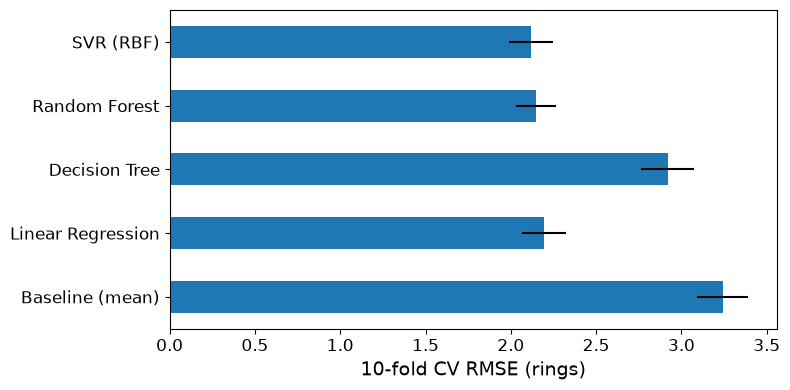

In [29]:
# Horizontal bar chart of mean CV RMSE per model; error bars show the standard deviation across folds
cv_table["CV RMSE mean"].plot(kind="barh", figsize=(8,4), xerr=cv_table["CV RMSE std"])
plt.xlabel("10-fold CV RMSE (rings)")
save_fig("cv_rmse_comparison")
plt.show()

# 6. Fine-Tune Your Model

## Grid Search
We search over a few Random Forest hyperparameters **and** over the `add_ratios` option of our custom transformer, so the search also tells us whether the engineered features help. To tune a preprocessing option, we put the pipeline and the model in one combined pipeline.

In [30]:
from sklearn.model_selection import GridSearchCV

# Combine preprocessing and the model in one pipeline so preprocessing options can be tuned too
full_pipeline_with_predictor = Pipeline([
    ("preparation", full_pipeline),
    ("forest", RandomForestRegressor(n_estimators=100, random_state=42)),
])

# Settings to try (2 x 3 x 3 = 18 combinations); the double-underscore names reach into nested steps
param_grid = {
    "preparation__num__attribs_adder__add_ratios": [True, False],   # include the ratio features or not
    "forest__max_features": [2, 4, 6],                              # features considered at each split
    "forest__min_samples_leaf": [1, 5, 10],                         # minimum samples per leaf (higher = smoother)
}

# Evaluate every combination with 10-fold CV, using all CPU cores (n_jobs=-1)
grid_search = GridSearchCV(full_pipeline_with_predictor, param_grid, cv=10,
                           scoring="neg_mean_squared_error",
                           return_train_score=True, n_jobs=-1)
grid_search.fit(abalone, abalone_labels)   # fit on raw training features; the pipeline handles preprocessing
grid_search.best_params_                   # the best combination found

{'forest__max_features': 4,
 'forest__min_samples_leaf': 10,
 'preparation__num__attribs_adder__add_ratios': True}

In [31]:
# Collect the CV score of every combination, sorted from best (lowest RMSE) to worst
cvres = grid_search.cv_results_
results = pd.DataFrame({
    "RMSE": np.sqrt(-cvres["mean_test_score"]),   # undo the negative sign, then take the square root
    "params": cvres["params"],
}).sort_values("RMSE")
pd.set_option("display.max_colwidth", None)   # show the full parameter dictionaries
results.head(8)                               # top 8 combinations

,RMSE,params
10,2.104495,"{'forest__max_features': 4, 'forest__min_samples_leaf': 10, 'preparation__num__attribs_adder__add_ratios': True}"
16,2.106498,"{'forest__max_features': 6, 'forest__min_samples_leaf': 10, 'preparation__num__attribs_adder__add_ratios': True}"
14,2.109361,"{'forest__max_features': 6, 'forest__min_samples_leaf': 5, 'preparation__num__attribs_adder__add_ratios': True}"
8,2.112056,"{'forest__max_features': 4, 'forest__min_samples_leaf': 5, 'preparation__num__attribs_adder__add_ratios': True}"
2,2.113440,"{'forest__max_features': 2, 'forest__min_samples_leaf': 5, 'preparation__num__attribs_adder__add_ratios': True}"
4,2.115432,"{'forest__max_features': 2, 'forest__min_samples_leaf': 10, 'preparation__num__attribs_adder__add_ratios': True}"
0,2.130434,"{'forest__max_features': 2, 'forest__min_samples_leaf': 1, 'preparation__num__attribs_adder__add_ratios': True}"
12,2.137662,"{'forest__max_features': 6, 'forest__min_samples_leaf': 1, 'preparation__num__attribs_adder__add_ratios': True}"


The tuned forest (CV RMSE ≈ 2.10) now slightly beats the untuned SVR. Larger `min_samples_leaf` values work best, and every top configuration keeps the ratio features: forcing each leaf to average several abalone smooths out noise instead of memorizing individual animals. This makes sense given how much age varies among abalone of the same size.

## Analyze the Best Model and Its Errors

In [32]:
# Best model found by the grid search (already refit on the full training set)
final_pipeline = grid_search.best_estimator_
feature_importances = final_pipeline.named_steps["forest"].feature_importances_

# Rebuild the feature names in the same order as the pipeline's output columns
uses_ratios = grid_search.best_params_["preparation__num__attribs_adder__add_ratios"]
extra_attribs = ["volume", "shell_ratio", "shucked_ratio"] if uses_ratios else ["volume"]
cat_one_hot_attribs = list(full_pipeline.named_transformers_["cat"].categories_[0])
attributes = num_attribs + extra_attribs + ["Sex_" + c for c in cat_one_hot_attribs]
# Pair each importance with its name, most important first
sorted(zip(feature_importances.round(4), attributes), reverse=True)

[(np.float64(0.2769), 'Shell_weight'),
 (np.float64(0.1997), 'shucked_ratio'),
 (np.float64(0.1047), 'volume'),
 (np.float64(0.077), 'shell_ratio'),
 (np.float64(0.0734), 'Viscera_weight'),
 (np.float64(0.0727), 'Height'),
 (np.float64(0.0623), 'Whole_weight'),
 (np.float64(0.0406), 'Length'),
 (np.float64(0.039), 'Diameter'),
 (np.float64(0.0328), 'Shucked_weight'),
 (np.float64(0.0128), 'Sex_I'),
 (np.float64(0.0041), 'Sex_F'),
 (np.float64(0.004), 'Sex_M')]

# 7. Evaluate Your System on the Test Set
Only now do we touch the test set — exactly once, with the final model. The pipeline applies the same cleaning, imputation, and scaling learned from the training set; it is **not** refit on test data.

In [33]:
# Separate the test set into features and labels
X_test = strat_test_set.drop("Rings", axis=1)
y_test = strat_test_set["Rings"].copy()

# Predict with the final pipeline: it only transforms (does not refit) using what it learned from the training set
final_predictions = final_pipeline.predict(X_test)

# Test-set error of the final model
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
final_mae = mean_absolute_error(y_test, final_predictions)

# Baseline for context: always predict the training-set mean ring count
baseline_pred = np.full(len(y_test), abalone_labels.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"Test RMSE: {final_rmse:.3f} rings   (baseline {baseline_rmse:.3f})")
print(f"Test MAE:  {final_mae:.3f} rings   (baseline {baseline_mae:.3f})")

Test RMSE: 2.085 rings   (baseline 3.143)
Test MAE:  1.474 rings   (baseline 2.347)


In [34]:
from scipy import stats

# 95% confidence interval for the test RMSE:
# build an interval for the mean squared error, then take the square root of both ends
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

array([1.88376781, 2.26758975])

Saving figure test_predicted_vs_actual


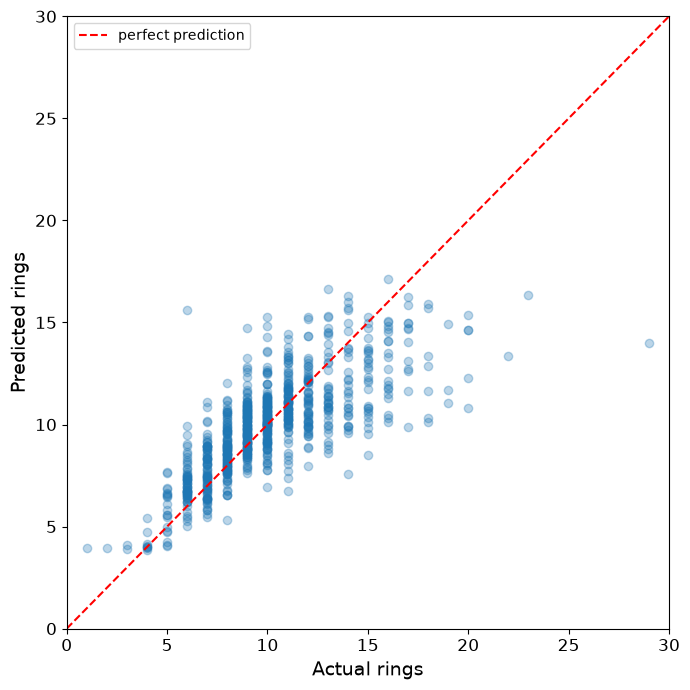

In [35]:
# Predicted vs. actual ring counts on the test set
plt.figure(figsize=(7,7))
plt.scatter(y_test, final_predictions, alpha=0.3)
lims = [0, 30]
plt.plot(lims, lims, "r--", label="perfect prediction")   # points on this line are exact predictions
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual rings"); plt.ylabel("Predicted rings")
plt.legend()
save_fig("test_predicted_vs_actual")
plt.show()

In [36]:

# Absolute error for each test abalone, grouped by actual age range
errors = pd.DataFrame({"actual": y_test, "abs_error": np.abs(final_predictions - y_test)})
errors["age_group"] = pd.cut(errors["actual"], bins=[0, 7, 11, 15, 30],
                             labels=["1-7", "8-11", "12-15", "16+"])
# Count and mean error per group, to see where the model struggles (e.g., older abalone)
errors.groupby("age_group", observed=True)["abs_error"].agg(["count", "mean"]).round(2)

,count,mean
age_group,,
1-7,171,1.19
8-11,460,1.08
12-15,155,2.02
16+,50,4.37


# 8. Launch, Monitor, and Maintain Your System

The final pipeline (preprocessing + model) is saved as a single object, so new measurements can be fed in as raw values and the same cleaning and scaling are applied automatically.

In [37]:
import joblib

# Save the whole pipeline (preprocessing + model) to a single file, then load it back
joblib.dump(final_pipeline, "abalone_model.pkl")
loaded_model = joblib.load("abalone_model.pkl")

# Example new abalone with raw (unscaled) measurements; the pipeline handles all preprocessing
new_abalone = pd.DataFrame([{"Sex": "F", "Length": 0.55, "Diameter": 0.43, "Height": 0.15,
                             "Whole_weight": 0.85, "Shucked_weight": 0.36,
                             "Viscera_weight": 0.18, "Shell_weight": 0.25}])
print("Predicted rings:", loaded_model.predict(new_abalone).round(1))

Predicted rings: [10.3]



# Dataset Link
Abalone dataset, UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/1/abalone